# **Pemodelan Supervised Learning & Evaluasi Algoritma Klasifikasi dan Regresi**
Catatan ini menyajikan implementasi praktis beserta landasan teoretis dari algoritma-algoritma utama dalam Supervised Learning (Pembelajaran Terbimbing). Eksplorasi ini mencakup algoritma K-Nearest Neighbors (KNN), Model Linier, Decision Trees, Random Forests, hingga Support Vector Machines (SVM).

## **Bagian 1: Konsep Dasar Generalisasi & Persiapan Dataset**
Tujuan utama dari supervised learning adalah membangun model menggunakan data latih sedemikian rupa sehingga model tersebut memiliki kemampuan generalisasi yang tinggi, yakni mampu memprediksi data uji (data yang belum pernah dilihat) dengan akurat. Terdapat dua masalah utama yang sering muncul selama proses pelatihan:

Overfitting: Kondisi di mana model terlalu kompleks sehingga "menghafal" detail dan derau *(noise)* pada data latih. Akibatnya, model berkinerja buruk pada data uji.

Underfitting: Kondisi di mana model terlalu sederhana untuk menangkap pola fundamental dalam data, menghasilkan akurasi yang rendah baik pada data latih maupun data uji.

Semua pustaka utama berhasil dimuat.


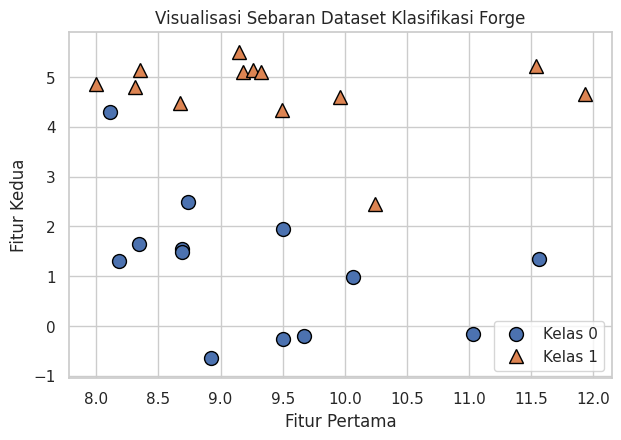

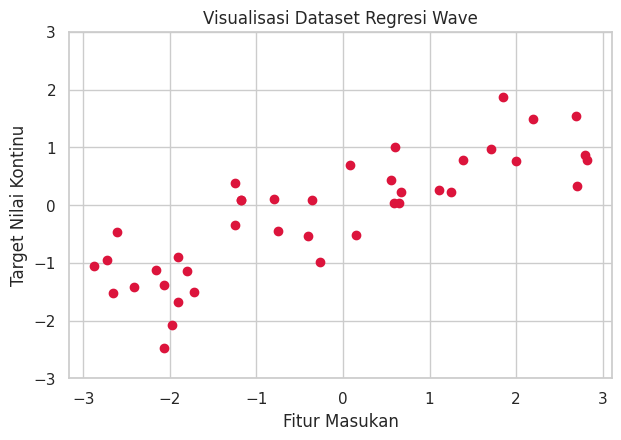

Dataset Kanker Payudara - Dimensi Data: (569, 30)
Dataset Perumahan California - Dimensi Data Awal: (20640, 8)
Dimensi Perumahan setelah ekspansi polinomial: (20640, 44)


In [9]:
# Setup environment dan instalasi pustaka pendukung
!pip install mglearn seaborn

# Memuat pustaka komputasi dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

# Memuat modul scikit-learn untuk pemodelan dan dataset
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Konfigurasi visualisasi
%matplotlib inline
sns.set_theme(style="whitegrid")
print("Semua pustaka utama berhasil dimuat.")

# 1. Eksplorasi Dataset Sintetis Klasifikasi (Forge)
X_forge, y_forge = mglearn.datasets.make_forge()
plt.figure(figsize=(7, 4.5))
mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge)
plt.legend(["Kelas 0", "Kelas 1"], loc=4)
plt.title("Visualisasi Sebaran Dataset Klasifikasi Forge")
plt.xlabel("Fitur Pertama")
plt.ylabel("Fitur Kedua")
plt.show()

# 2. Eksplorasi Dataset Sintetis Regresi (Wave)
X_wave, y_wave = mglearn.datasets.make_wave(n_samples=40)
plt.figure(figsize=(7, 4.5))
plt.plot(X_wave, y_wave, 'o', color='crimson')
plt.ylim(-3, 3)
plt.title("Visualisasi Dataset Regresi Wave")
plt.xlabel("Fitur Masukan")
plt.ylabel("Target Nilai Kontinu")
plt.show()

# 3. Memuat Dataset Riil
kanker = load_breast_cancer()
perumahan = fetch_california_housing()

# Rekayasa Fitur: Interaksi polinomial untuk mendemonstrasikan kompleksitas
fitur_polinomial = PolynomialFeatures(degree=2, include_bias=False)
X_perumahan_luas = fitur_polinomial.fit_transform(perumahan.data)

print(f"Dataset Kanker Payudara - Dimensi Data: {kanker.data.shape}")
print(f"Dataset Perumahan California - Dimensi Data Awal: {perumahan.data.shape}")
print(f"Dimensi Perumahan setelah ekspansi polinomial: {X_perumahan_luas.shape}")

# **Persiapan Pustaka dan Dataset**
Blok kode di bawah ini memuat pustaka analisis data utama dan menyiapkan beberapa dataset referensi, baik sintetis (Forge dan Wave) maupun riil (Kanker Payudara dan Perumahan California).

Semua pustaka utama berhasil dimuat.


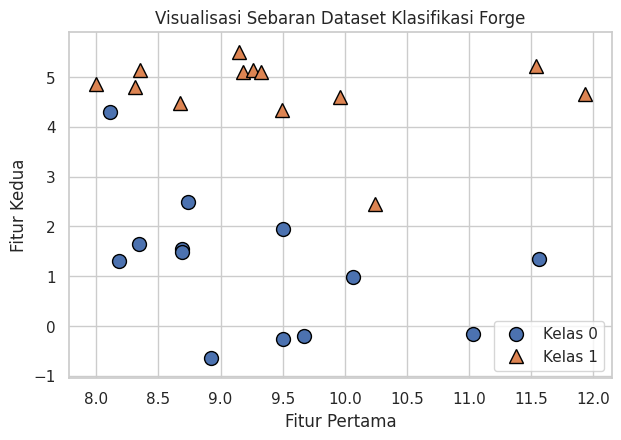

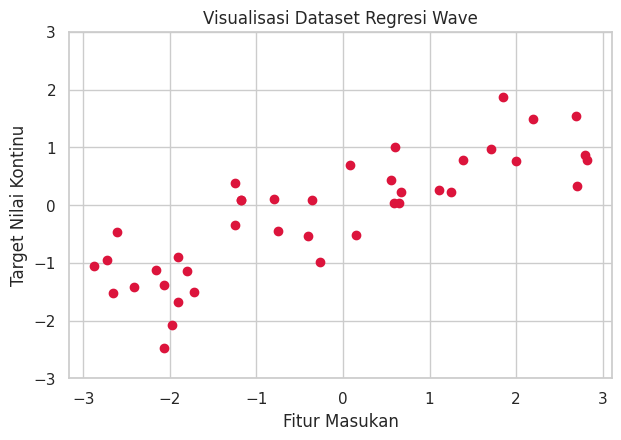

Dataset Kanker Payudara - Dimensi Data: (569, 30)
Dataset Perumahan California - Dimensi Data Awal: (20640, 8)
Dimensi Perumahan setelah ekspansi polinomial: (20640, 44)


In [10]:
# Setup environment dan instalasi pustaka pendukung
!pip install mglearn seaborn

# Memuat pustaka komputasi dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

# Memuat modul scikit-learn untuk pemodelan dan dataset
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Konfigurasi visualisasi
%matplotlib inline
sns.set_theme(style="whitegrid")
print("Semua pustaka utama berhasil dimuat.")

# 1. Eksplorasi Dataset Sintetis Klasifikasi (Forge)
X_forge, y_forge = mglearn.datasets.make_forge()
plt.figure(figsize=(7, 4.5))
mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge)
plt.legend(["Kelas 0", "Kelas 1"], loc=4)
plt.title("Visualisasi Sebaran Dataset Klasifikasi Forge")
plt.xlabel("Fitur Pertama")
plt.ylabel("Fitur Kedua")
plt.show()

# 2. Eksplorasi Dataset Sintetis Regresi (Wave)
X_wave, y_wave = mglearn.datasets.make_wave(n_samples=40)
plt.figure(figsize=(7, 4.5))
plt.plot(X_wave, y_wave, 'o', color='crimson')
plt.ylim(-3, 3)
plt.title("Visualisasi Dataset Regresi Wave")
plt.xlabel("Fitur Masukan")
plt.ylabel("Target Nilai Kontinu")
plt.show()

# 3. Memuat Dataset Riil
kanker = load_breast_cancer()
perumahan = fetch_california_housing()

# Rekayasa Fitur: Interaksi polinomial untuk mendemonstrasikan kompleksitas
fitur_polinomial = PolynomialFeatures(degree=2, include_bias=False)
X_perumahan_luas = fitur_polinomial.fit_transform(perumahan.data)

print(f"Dataset Kanker Payudara - Dimensi Data: {kanker.data.shape}")
print(f"Dataset Perumahan California - Dimensi Data Awal: {perumahan.data.shape}")
print(f"Dimensi Perumahan setelah ekspansi polinomial: {X_perumahan_luas.shape}")

# **Bagian 2: K-Nearest Neighbors (KNN)**
Algoritma KNN merupakan pendekatan non-parametrik yang melakukan prediksi berdasarkan kedekatan jarak. Model akan mengklasifikasikan titik data baru berdasarkan mayoritas kelas dari sejumlah $K$ tetangga terdekatnya. Nilai $K$ sangat memengaruhi batas keputusan (decision boundary): nilai $K$ yang kecil menghasilkan batas yang sangat kompleks (rentan overfitting), sedangkan nilai $K$ yang besar menghasilkan batas yang lebih halus (berpotensi underfitting).

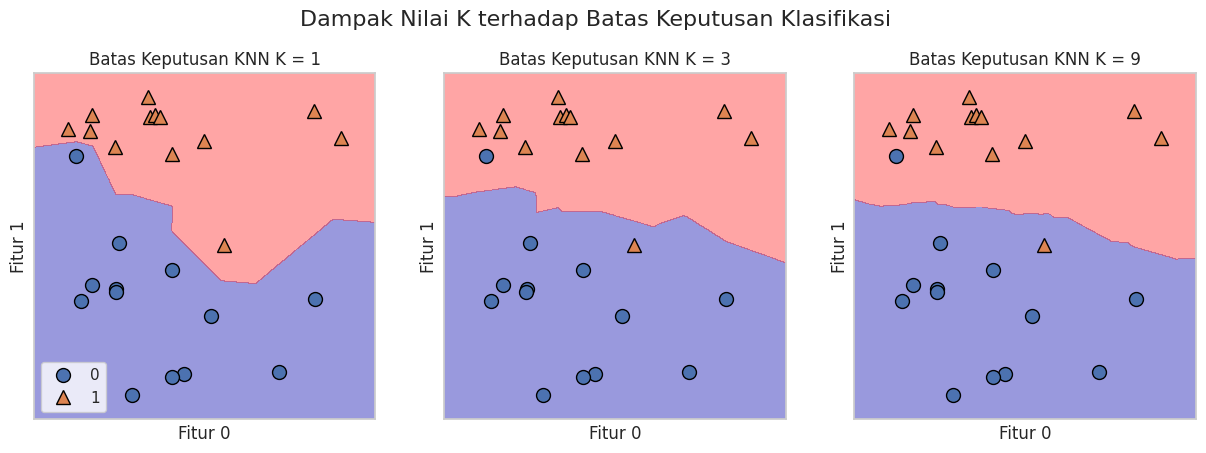

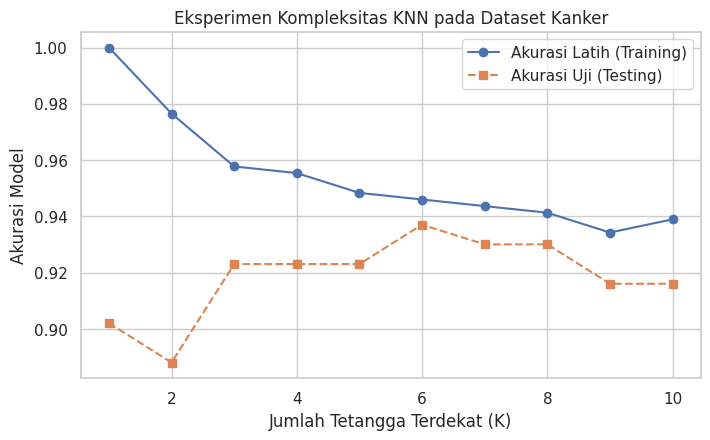

In [20]:
# Visualisasi pengaruh parameter K terhadap batas keputusan (Decision Boundary)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for k, ax in zip([1, 3, 9], axes):
    model_knn = KNeighborsClassifier(n_neighbors=k).fit(X_forge, y_forge)
    mglearn.plots.plot_2d_separator(model_knn, X_forge, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge, ax=ax)
    ax.set_title(f"Batas Keputusan KNN K = {k}")
    ax.set_xlabel("Fitur 0")
    ax.set_ylabel("Fitur 1")
axes[0].legend(loc=3)
plt.suptitle("Dampak Nilai K terhadap Batas Keputusan Klasifikasi", y=1.02, fontsize=16)
plt.show()

# Evaluasi Kompleksitas KNN menggunakan Dataset Kanker
X_train_kanker, X_test_kanker, y_train_kanker, y_test_kanker = train_test_split(
    kanker.data, kanker.target, stratify=kanker.target, random_state=66
)

kurva_latih, kurva_uji = [], []
daftar_k = range(1, 11)

for k in daftar_k:
    clf = KNeighborsClassifier(n_neighbors=k).fit(X_train_kanker, y_train_kanker)
    kurva_latih.append(clf.score(X_train_kanker, y_train_kanker))
    kurva_uji.append(clf.score(X_test_kanker, y_test_kanker))
# Visualisasi kurva akurasi Latih vs Uji
plt.figure(figsize=(8, 4.5))
plt.plot(daftar_k, kurva_latih, label="Akurasi Latih (Training)", marker='o')
plt.plot(daftar_k, kurva_uji, label="Akurasi Uji (Testing)", marker='s', linestyle='--')
plt.xlabel("Jumlah Tetangga Terdekat (K)")
plt.ylabel("Akurasi Model")
plt.title("Eksperimen Kompleksitas KNN pada Dataset Kanker")
plt.legend()
plt.show()

# **Bagian 3: Model Linier (Linear Models)**
Model linier bekerja dengan membuat kombinasi linier dari fitur masukan untuk menghasilkan prediksi. Untuk regresi, pendekatan standar seperti Ordinary Least Squares (OLS) rentan terhadap overfitting pada dimensi tinggi. Oleh karena itu, diterapkan teknik regularisasi untuk mengendalikan kompleksitas model:Ridge Regression ($L_2$ Regularization): Menekan nilai koefisien fitur agar mendekati nol.Lasso Regression ($L_1$ Regularization): Mampu mengeliminasi fitur yang tidak relevan dengan mengatur koefisiennya menjadi tepat nol (feature selection inheren).

In [12]:
# Mempartisi dataset perumahan dimensi tinggi
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_perumahan_luas, perumahan.target, random_state=42
)

# 1. Linear Regression Standar (OLS)
model_ols = LinearRegression().fit(X_train_h, y_train_h)

# 2. Ridge Regression (Penalti L2)
model_ridge_1 = Ridge(alpha=1.0).fit(X_train_h, y_train_h)

# 3. Lasso Regression (Penalti L1)
model_lasso_001 = Lasso(alpha=0.01, max_iter=10000).fit(X_train_h, y_train_h)

print("=== Komparasi Performa Model Regresi Linier ===")
print(f"OLS Skor R2 Uji   : {model_ols.score(X_test_h, y_test_h):.4f}")
print(f"Ridge (alpha=1.0) R2 Uji: {model_ridge_1.score(X_test_h, y_test_h):.4f}")
print(f"Lasso (alpha=0.01) R2 Uji: {model_lasso_001.score(X_test_h, y_test_h):.4f}")
print(f"Jumlah fitur relevan pada Lasso: {np.sum(model_lasso_001.coef_ != 0)} dari 44 fitur")

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.57615e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


=== Komparasi Performa Model Regresi Linier ===
OLS Skor R2 Uji   : 0.6563
Ridge (alpha=1.0) R2 Uji: 0.6730
Lasso (alpha=0.01) R2 Uji: 0.6585
Jumlah fitur relevan pada Lasso: 34 dari 44 fitur


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.507e+03, tolerance: 2.066e+00
  model = cd_fast.enet_coordinate_descent(


# **Bagian 4: Decision Trees & Random Forests**
Decision Tree bekerja dengan membangun hierarki aturan biner (ya/tidak) untuk mempartisi ruang data. Meskipun sangat interpretabel, pohon keputusan tunggal sangat rentan memori data secara berlebihan (overfitting). Untuk mengatasi hal ini, digunakan Random Forest, yaitu metode ensemble yang membangun banyak pohon keputusan secara acak dan menggabungkan prediksinya melalui sistem voting mayoritas.

=== Komparasi Decision Tree vs Random Forest ===
Akurasi Uji Decision Tree : 0.9021
Akurasi Uji Random Forest : 0.9580


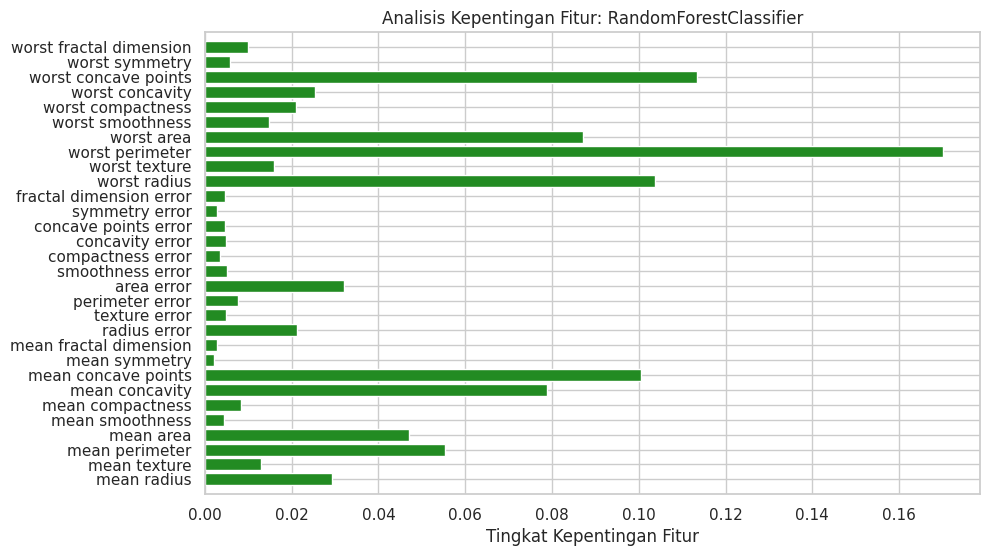

In [13]:
# Melatih Decision Tree dengan pembatasan kedalaman (pruning)
pohon = DecisionTreeClassifier(max_depth=4, random_state=0)
pohon.fit(X_train_kanker, y_train_kanker)

# Melatih Random Forest Classifier (100 pohon)
hutan = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train_kanker, y_train_kanker)

print("=== Komparasi Decision Tree vs Random Forest ===")
print(f"Akurasi Uji Decision Tree : {pohon.score(X_test_kanker, y_test_kanker):.4f}")
print(f"Akurasi Uji Random Forest : {hutan.score(X_test_kanker, y_test_kanker):.4f}")

# Fungsi untuk visualisasi tingkat kepentingan fitur
def visualisasi_feature_importances(model, dataset_raw):
    jumlah_fitur = dataset_raw.data.shape[1]
    plt.figure(figsize=(10, 6))
    plt.barh(range(jumlah_fitur), model.feature_importances_, align='center', color='forestgreen')
    plt.yticks(np.arange(jumlah_fitur), dataset_raw.feature_names)
    plt.xlabel("Tingkat Kepentingan Fitur")
    plt.title(f"Analisis Kepentingan Fitur: {model.__class__.__name__}")
    plt.ylim(-1, jumlah_fitur)

visualisasi_feature_importances(hutan, kanker)
plt.show()

# **Bagian 5: Support Vector Machines (SVM)**
SVM linier mencari batas pemisah (hiperbidang) optimal antar kelas. Untuk data yang tidak dapat dipisahkan secara linier, digunakan konsep Kernel Trick (seperti Radial Basis Function / RBF) untuk memproyeksikan data ke dimensi yang lebih tinggi agar dapat dipisahkan secara linier. SVM sangat sensitif terhadap magnitudo jarak, sehingga penskalaan fitur (misalnya dengan MinMaxScaler) merupakan tahapan prapemrosesan yang mutlak diperlukan.

In [14]:
# Evaluasi SVM tanpa penskalaan data
model_svm = SVC(C=10, gamma=0.1).fit(X_train_kanker, y_train_kanker)
print("=== SVM Sebelum Fitur Diskala ===")
print(f"Akurasi Latih : {model_svm.score(X_train_kanker, y_train_kanker):.4f}")
print(f"Akurasi Uji   : {model_svm.score(X_test_kanker, y_test_kanker):.4f}")

# Menerapkan MinMaxScaler untuk merubah rentang fitur menjadi 0-1
skaler = MinMaxScaler()
X_train_scaled = skaler.fit_transform(X_train_kanker)
X_test_scaled = skaler.transform(X_test_kanker)

# Pelatihan ulang SVM dengan data yang terskala
model_svm_scaled = SVC(C=10, gamma=0.1).fit(X_train_scaled, y_train_kanker)
print("\n=== SVM Setelah Fitur Diskala ===")
print(f"Akurasi Latih : {model_svm_scaled.score(X_train_scaled, y_train_kanker):.4f}")
print(f"Akurasi Uji   : {model_svm_scaled.score(X_test_scaled, y_test_kanker):.4f}")

=== SVM Sebelum Fitur Diskala ===
Akurasi Latih : 1.0000
Akurasi Uji   : 0.6294

=== SVM Setelah Fitur Diskala ===
Akurasi Latih : 0.9836
Akurasi Uji   : 0.9720


# **Bagian 6 & 7: Estimasi Ketidakpastian dan Alur Kerja Terintegrasi**
Pustaka scikit-learn memfasilitasi inspeksi probabilitas dan keyakinan model terhadap suatu prediksi melalui metode predict_proba (rentang probabilitas 0-1) dan decision_function (metrik jarak menuju hiperbidang pemisah). Secara keseluruhan, pipeline standar pemodelan klasifikasi mencakup tahapan: pemisahan data, penskalaan fitur, pelatihan model, dan evaluasi.

In [15]:
# Pipeline Alur Kerja Terintegrasi
X_latih, X_uji, y_latih, y_uji = train_test_split(
    kanker.data, kanker.target, random_state=42
)

# 1. Prapemrosesan (Penskalaan)
skaler_final = MinMaxScaler()
X_latih_skala = skaler_final.fit_transform(X_latih)
X_uji_skala = skaler_final.transform(X_uji)

# 2. Pelatihan Model (SVM Kernel RBF)
svm_final = SVC(C=1.0, kernel='rbf', gamma='scale', probability=True).fit(X_latih_skala, y_latih)

# 3. Evaluasi
print(f"Akurasi Akhir Pipeline Terintegrasi: {svm_final.score(X_uji_skala, y_uji):.4f}")

# 4. Inspeksi Ketidakpastian Prediksi
print("\nProbabilitas Prediksi (5 Sampel Pertama Kelas Negatif vs Positif):")
print(svm_final.predict_proba(X_uji_skala)[:5])

Akurasi Akhir Pipeline Terintegrasi: 0.9790

Probabilitas Prediksi (5 Sampel Pertama Kelas Negatif vs Positif):
[[2.11238962e-02 9.78876104e-01]
 [9.99746334e-01 2.53666397e-04]
 [9.98413193e-01 1.58680723e-03]
 [1.28140303e-07 9.99999872e-01]
 [8.67957541e-09 9.99999991e-01]]
